In [1]:
import os
import re
import pandas as pd
import nilearn as nl
import numpy as np
import seaborn as sns
from nilearn.input_data import NiftiMasker
from nilearn.image.image import mean_img
from nilearn import plotting, image
from nilearn.plotting import view_img
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from nilearn.image import math_img



/opt/anaconda3/lib/python3.8/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


# Making anatomical Masks and getting files

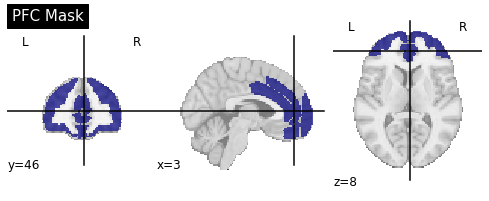

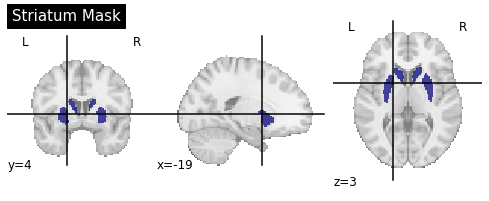

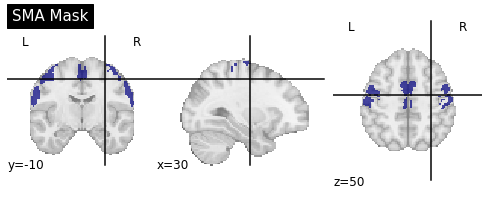

In [2]:
from nilearn import image,datasets,masking,plotting,input_data
#Striatum Mask

f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
    '../derivatives/') for f in files if f.endswith('desc-preproc_bold.nii.gz')]

HO_sub=datasets.fetch_atlas_harvard_oxford(atlas_name='sub-maxprob-thr50-2mm')

keep = [idx for idx, s in enumerate(HO_sub.labels) if
        'Accumbens' in s or
        'Caudate' in s or
        'Putamen' in s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_sub.maps) for idx in keep]   

str_regions=image.concat_imgs(np.array(keepimg_list))
str_mask=masking.compute_background_mask(str_regions)
str_mask=NiftiMasker(mask_img=str_mask)

#MPFC mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Frontal Medial Cortex'==s or
        'Frontal Pole'==s or
        'Frontal Orbital Cortex'==s or
        'Cingulate Gyrus, anterior division'==s or
        'Paracingulate Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

cort_regions=image.concat_imgs(np.array(keepimg_list))
cort_mask=masking.compute_background_mask(cort_regions)
cort_mask=NiftiMasker(mask_img=cort_mask)

#SMA mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Juxtapositional Lobule Cortex' in s or
        'Precentral Gyrus'==s or
        'Postcentral Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

SMA_regions=image.concat_imgs(np.array(keepimg_list))
SMA_mask=masking.compute_background_mask(SMA_regions)
SMA_mask=NiftiMasker(mask_img=SMA_mask)

plotting.plot_roi(cort_mask.mask_img,title="PFC Mask")
plt.show()
plotting.plot_roi(str_mask.mask_img,title='Striatum Mask')
plt.show()
plotting.plot_roi(SMA_mask.mask_img,title='SMA Mask')
plt.show()

# TSNR
- Heads up these Graphs are interactive

In [3]:
data=[]
img_list=[]
for img in f_list:

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('func/sub-(.*?)_task',img).group(1)
    mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
    
    nifti_masker = NiftiMasker(mask_strategy='epi')
    x=nifti_masker.fit_transform(img)
    img=nifti_masker.inverse_transform(x)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    img_list.append([tsnr_img,me,mb,sub])
    x=nifti_masker.fit_transform(tsnr_img)
    y=str_mask.fit_transform(tsnr_img)
    z=cort_mask.fit_transform(tsnr_img)
    data.append([sub,mb,me,np.mean(np.abs(x.flatten())),
                 np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))])

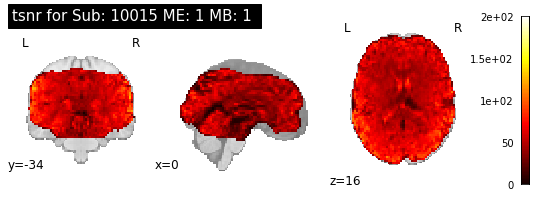

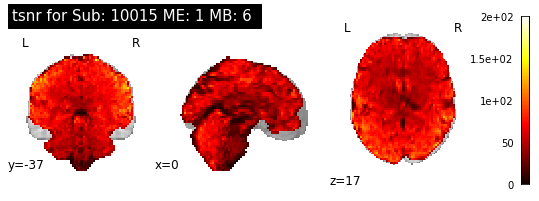

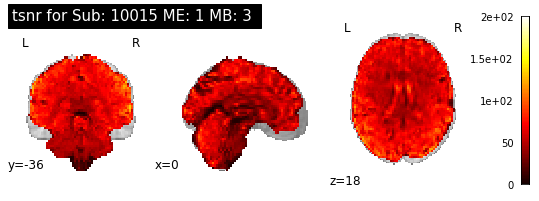

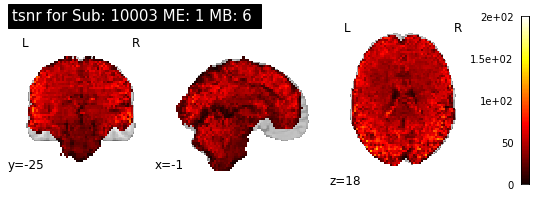

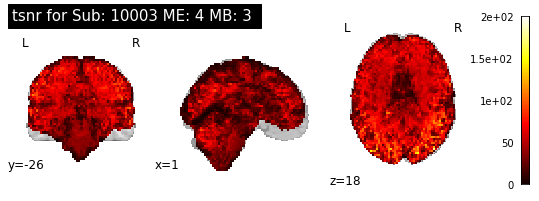

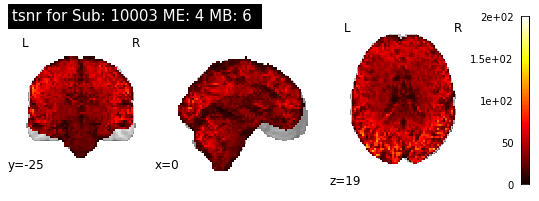

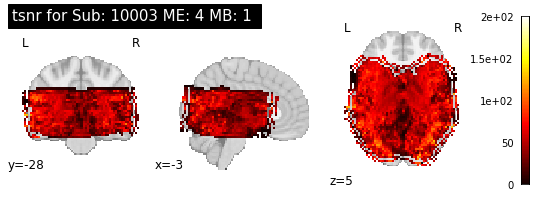

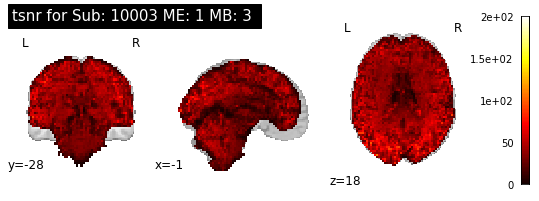

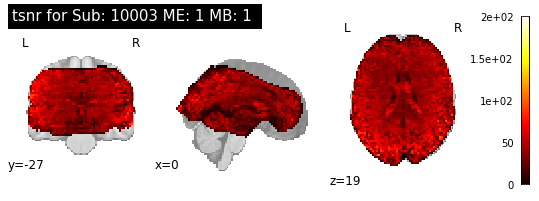

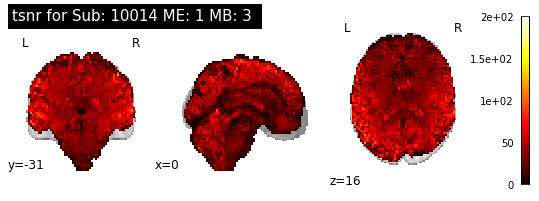

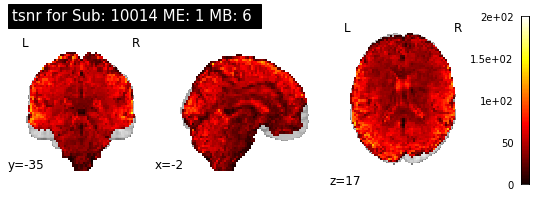

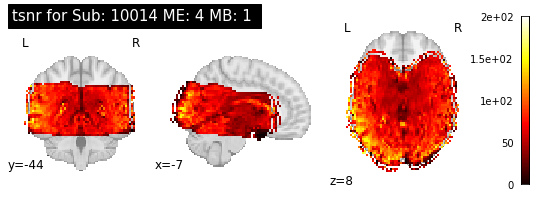

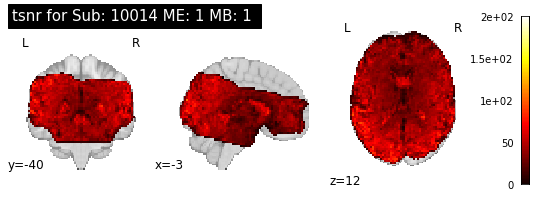

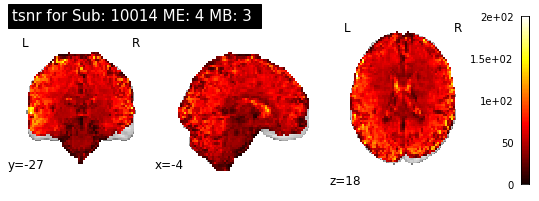

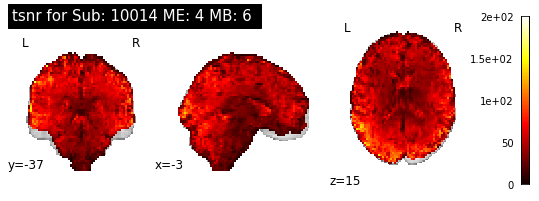

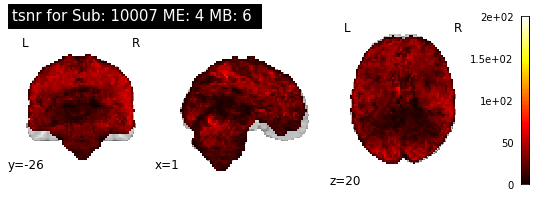

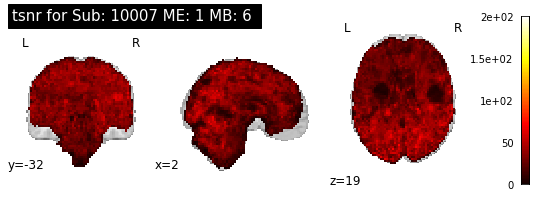

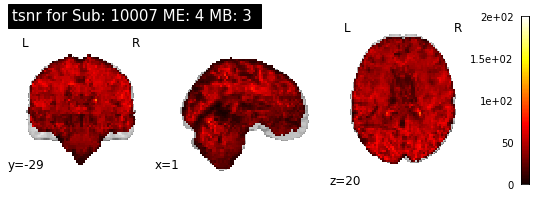

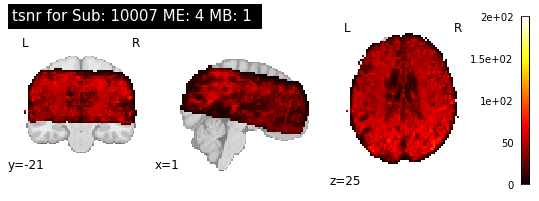

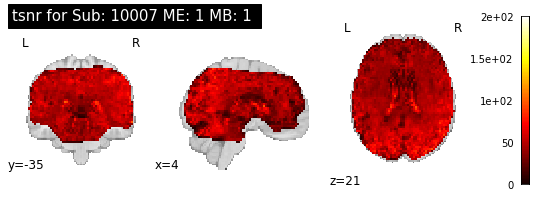

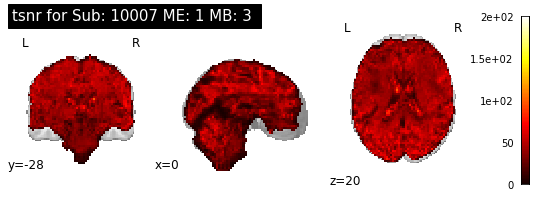

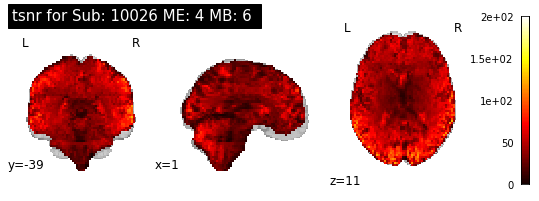

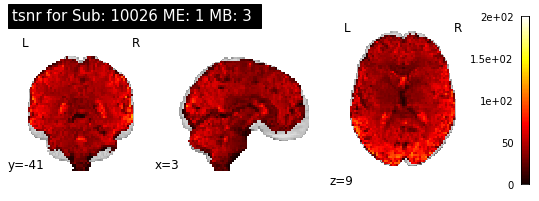

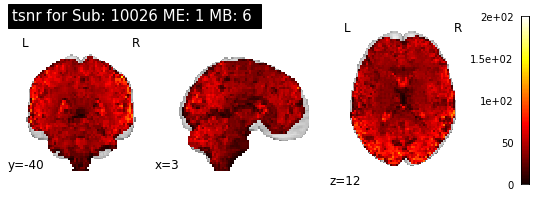

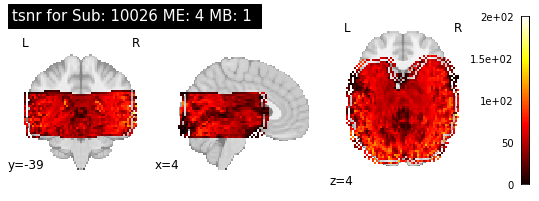

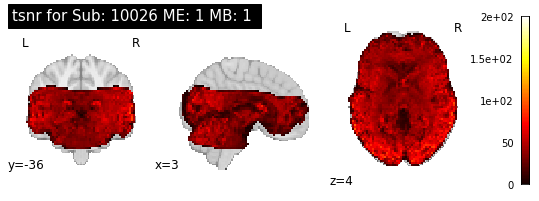

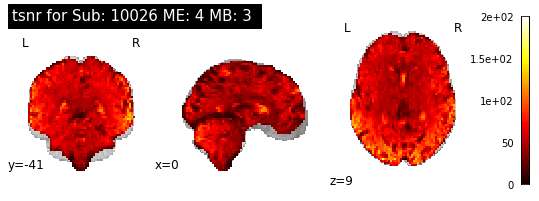

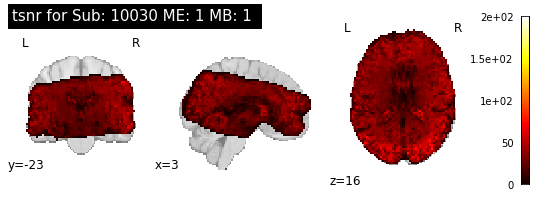

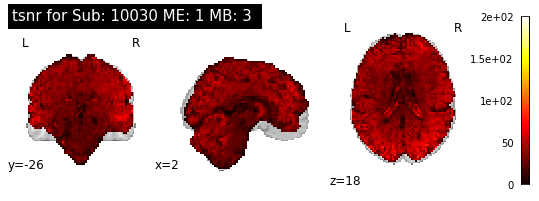

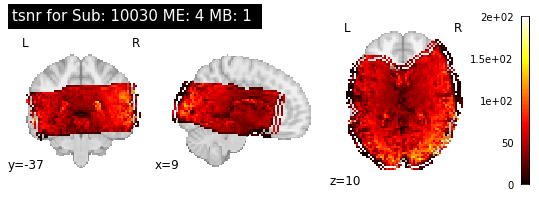

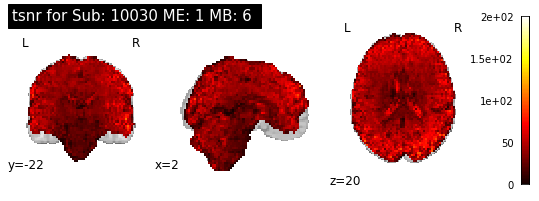

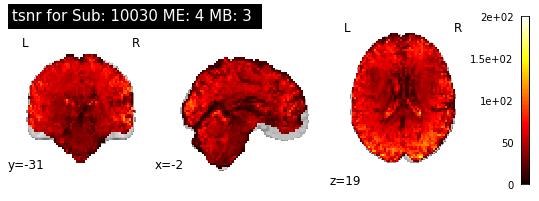

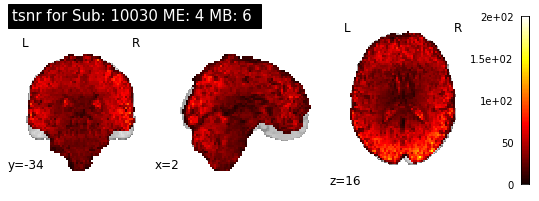

In [4]:
for img in img_list:
    plotting.plot_stat_map(img[0],
                      title="tsnr for Sub: %s ME: %s MB: %s "%(img[3],img[1],img[2]),
                      vmax=200,draw_cross=False)
    plt.show()


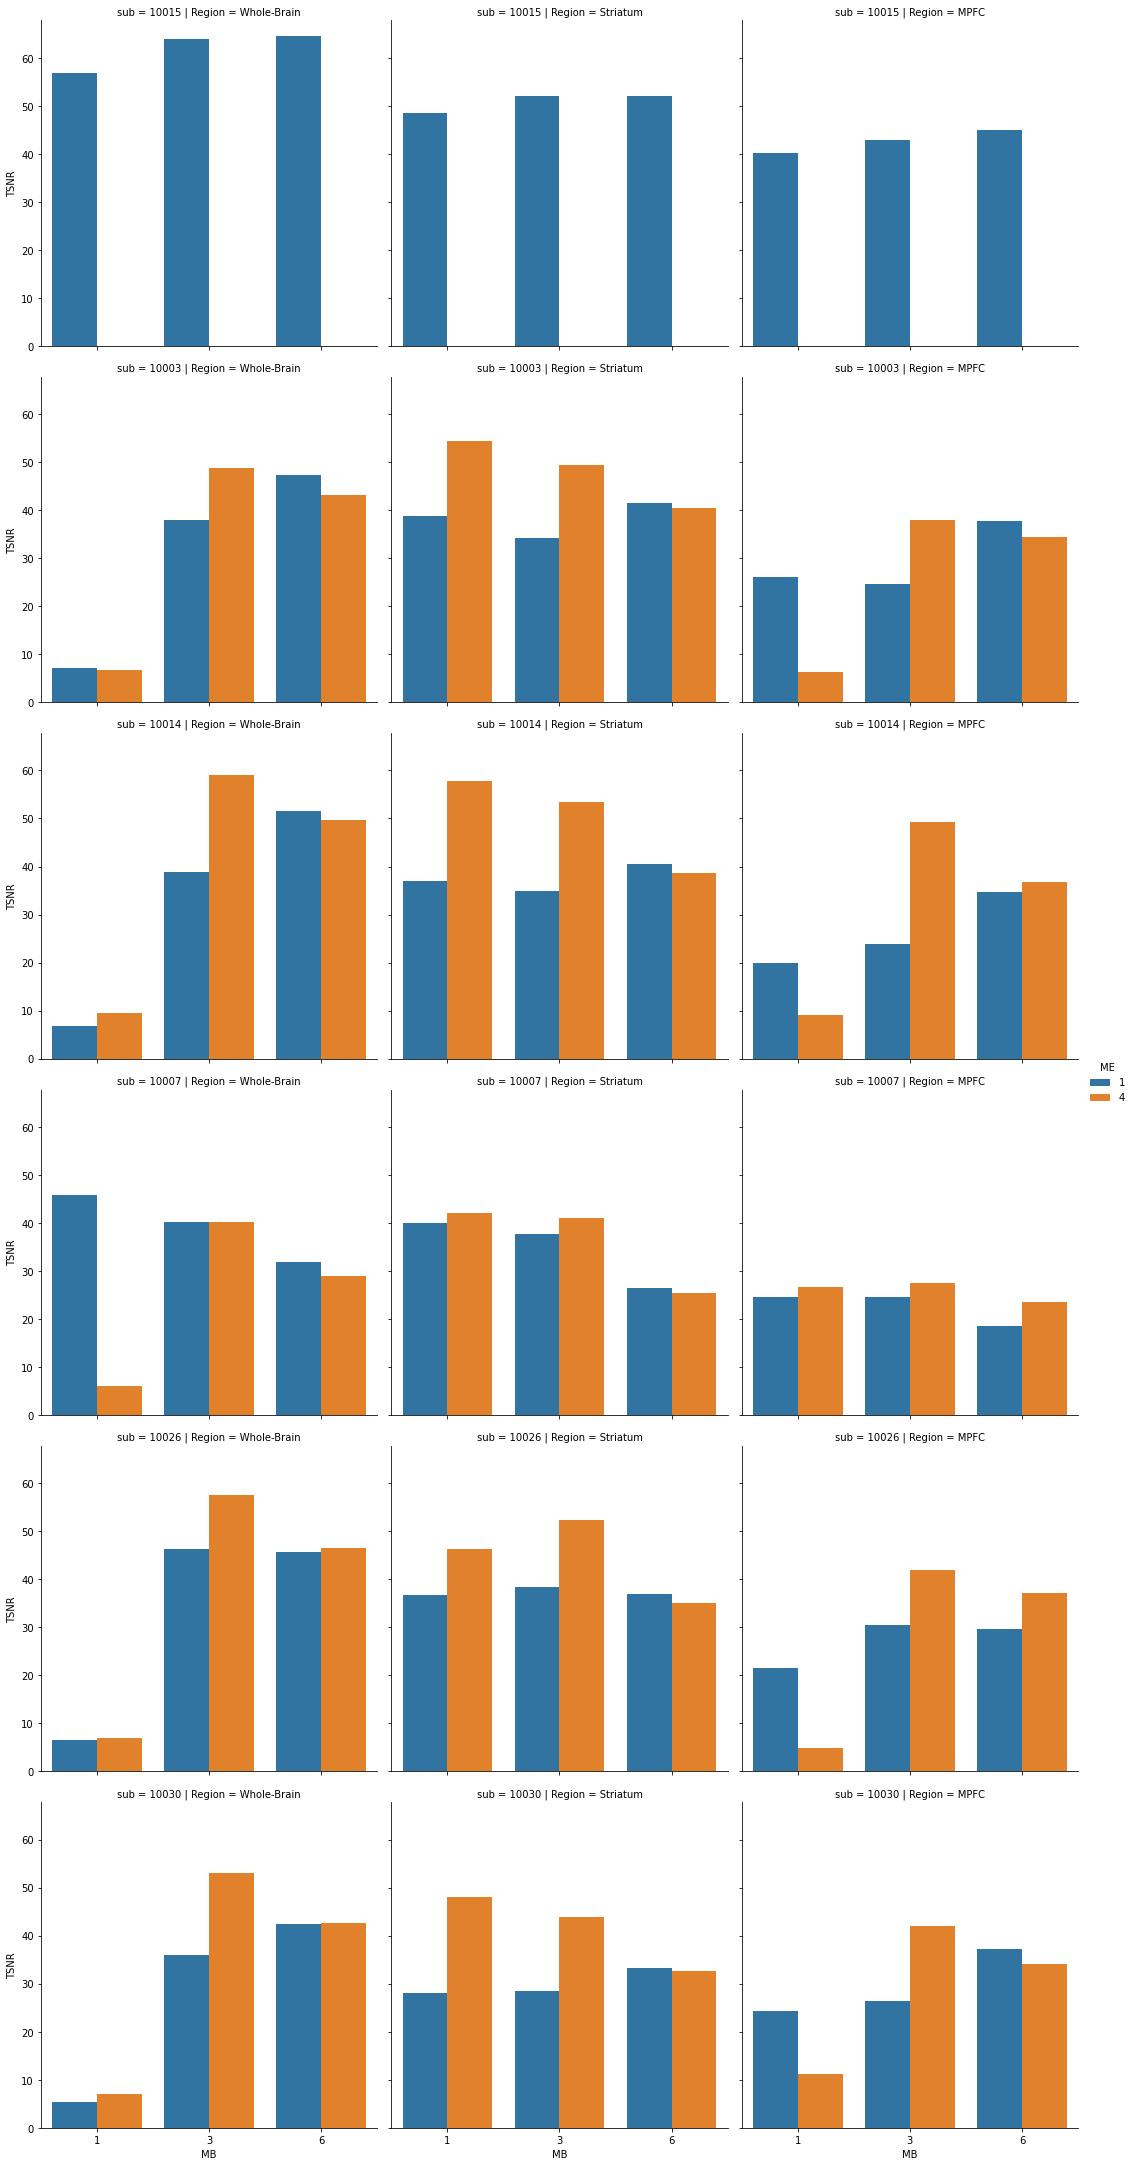

In [5]:

df=pd.DataFrame(data=data,columns=['sub','MB','ME','Whole-Brain','Striatum','MPFC'])
df=df.melt(id_vars=['sub','MB','ME'],var_name='Region',value_name='TSNR')
g=sns.catplot(x='MB',y='TSNR',hue='ME',data=df,col='Region',row='sub',kind='bar')
g.savefig('RF1-3subs_2regions.pdf')

# L1 Z-stats
- Heads up these Graphs are interactive

In [6]:
f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
    '../derivatives/fsl/') for f in files if ('thresh_zstat' in f) & f.endswith('.nii.gz')]#  ('stats' in root) &if ('/stats/zstat' in f) & (f.endswith('nii.gz'))]

In [7]:
import multiprocessing

def collect_zstats(img):
    zstat=int(re.search('thresh_zstat(.*).nii.gz',img).group(1))
    if zstat>10:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)

        nifti_masker = NiftiMasker(mask_strategy='background')
        x=nifti_masker.fit_transform(img)
        img=nifti_masker.inverse_transform(x)

        # calculate mean image for the background
    
        x=nifti_masker.fit_transform(img)
        y=str_mask.fit_transform(img)
        z=cort_mask.fit_transform(img)
        
        img_row=[str_mask.inverse_transform(y),img,zstat,me,mb,sub]

        data_row=[sub,mb,me,zstat,np.mean(np.abs(x.flatten())),
                     np.mean(np.abs(y.flatten())),
                     np.mean(np.abs(z.flatten()))]
        return(data_row)

def driver_func(myfunc,input_list):
    THREADS=4
    with multiprocessing.Pool(THREADS) as pool:
        data_res=[pool.apply_async(myfunc,p) for p in input_list]
        
driver_func(collect_zstats,f_list)

In [7]:
data=[]
img_list=[]
for img in f_list:
    
    zstat=int(re.search('thresh_zstat(.*).nii.gz',img).group(1))
    if zstat>10:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)

        nifti_masker = NiftiMasker(mask_strategy='background')
        x=nifti_masker.fit_transform(img)
        img=nifti_masker.inverse_transform(x)

        # calculate mean image for the background
    
        x=nifti_masker.fit_transform(img)
        y=str_mask.fit_transform(img)
        z=cort_mask.fit_transform(img)
        
        img_list.append([str_mask.inverse_transform(y),img,zstat,me,mb,sub])

        data.append([sub,mb,me,zstat,np.mean(np.abs(x.flatten())),
                     np.mean(np.abs(y.flatten())),
                     np.mean(np.abs(z.flatten()))])

AttributeError: 'NoneType' object has no attribute 'group'

In [ ]:

df=pd.DataFrame(data=data,columns=['sub','MB','ME','contrast','Whole-Brain','Striatum','MPFC'])
df=df.melt(id_vars=['contrast','sub','MB','ME'],var_name='Region',value_name='zstat')
g=sns.catplot(x='MB',y='zstat',hue='ME',data=df,col='Region',row='contrast',kind='bar',sharey=False)
g.savefig('RF1-zstat.pdf')